# Part 3: Predictive Analysis - ver2 (đã bỏ favorite_count & original_price)

Xây dựng **2 model hồi quy** (Random Forest + XGBoost) để dự đoán `quantity_sold`, dùng 7 numeric feature - đã loại `favorite_count` (variance=0, không mang thông tin) và `original_price` (tương quan 0.975 với `price`, thông tin đã được `discount_rate` encode lại). So với `train_model_ver1.ipynb` (đủ 9 feature) để xem RMSE/R²/feature importance đổi thế nào khi bỏ đa cộng tuyến.

In [2]:
import itertools
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [3]:
DATA_PATH = os.path.join("..", "Merge_Datasets", "merged_products.csv")
FIG_DIR = "figures_ver2"
OUT_DIR = "output_ver2"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42

NUMERIC_FEATURES = [
    "price",
    "discount_rate",
    "rating_average",
    "review_counts",
    "number_of_images",
    "vnd_cashback",
    "date_created",
]
BOOL_FEATURES = ["pay_later", "has_video", "is_branded"]
CATEGORICAL_FEATURES = ["sub_category", "fulfillment_type"]
TARGET = "quantity_sold"

MODEL_COLORS = {"random_forest": "#2a78d6", "xgboost": "#eb6834"}

df = pd.read_csv(DATA_PATH)
df.shape

(41576, 21)

## 0. Kiểm tra tương quan giữa các feature (đa cộng tuyến)

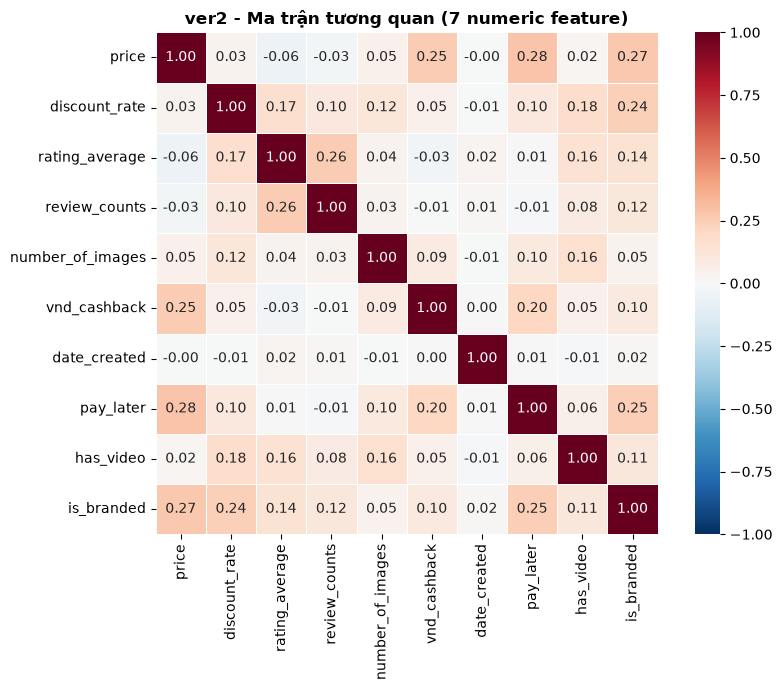

Cặp feature tương quan mạnh (|corr| > 0.5):
  (không có cặp nào)


In [4]:
corr_matrix = df[NUMERIC_FEATURES + BOOL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title(f"ver2 - Ma trận tương quan ({len(NUMERIC_FEATURES)} numeric feature)", fontsize=12, weight="bold")
fig.tight_layout()
plt.show()
''
print("Cặp feature tương quan mạnh (|corr| > 0.5):")
found = False
for a, b in itertools.combinations(corr_matrix.columns, 2):
    v = corr_matrix.loc[a, b]
    if abs(v) > 0.5:
        print(f"  {a} <-> {b}: {v:.3f}")
        found = True
if not found:
    print("  (không có cặp nào)")

## 1. Chuẩn bị dữ liệu cho mô hình

- Ép 3 cột bool về 0/1.
- One-hot encode `sub_category` và `fulfillment_type` (giữ `parent_of` để gộp importance one-hot về lại biến gốc sau này).
- Chia train/test 80/20 và chuẩn hóa các biến số bằng `StandardScaler` (chỉ fit trên train).

In [5]:
def build_feature_matrix(df: pd.DataFrame):
    X = df[NUMERIC_FEATURES + BOOL_FEATURES].copy()
    for col in BOOL_FEATURES:
        X[col] = X[col].astype(int)

    dummies = pd.get_dummies(df[CATEGORICAL_FEATURES], prefix=CATEGORICAL_FEATURES)
    parent_of = {}
    for col in dummies.columns:
        for parent in CATEGORICAL_FEATURES:
            if col.startswith(parent + "_"):
                parent_of[col] = parent
                break

    X = pd.concat([X, dummies], axis=1)
    y = df[TARGET].astype(float)
    return X, y, parent_of


X, y, parent_of = build_feature_matrix(df)
X.shape

(41576, 20)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 33260, Test rows: 8316


## 2. Xây dựng và Đánh giá Mô hình (Random Forest + XGBoost)

In [7]:
def aggregate_importance(model, feature_names, parent_of):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    agg = {}
    for feat, imp in importances.items():
        parent = parent_of.get(feat, feat)
        agg[parent] = agg.get(parent, 0.0) + float(imp)
    return importances.sort_values(ascending=False), pd.Series(agg).sort_values(ascending=False)


def train_and_evaluate(name, model, X_train, X_test, y_train, y_test, parent_of):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    raw_imp, agg_imp = aggregate_importance(model, X_train.columns, parent_of)
    raw_imp.to_csv(os.path.join(OUT_DIR, f"feature_importance_raw_onehot_{name}.csv"), header=["importance"])
    agg_imp.to_csv(os.path.join(OUT_DIR, f"feature_importance_aggregated_{name}.csv"), header=["importance"])

    print(f"\n=== {name} ===")
    print(f"RMSE: {rmse:.2f}  |  R2 Score: {r2:.4f}")
    print("Top 5 features:")
    print(agg_imp.head(5))

    return {"name": name, "model": model, "rmse": rmse, "r2": r2, "agg_importance": agg_imp}

In [8]:
models = {
    "random_forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "xgboost": XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.7,
        min_child_weight=5, gamma=1.0, reg_alpha=1.0, reg_lambda=3.0,
    )

}

results = [
    train_and_evaluate(name, model, X_train_scaled, X_test_scaled, y_train, y_test, parent_of)
    for name, model in models.items()
]

with open(os.path.join(OUT_DIR, "model_performance.txt"), "w") as f:
    f.write("=== Part 3 ver2: Predictive Analysis - Model Performance ===\n\n")
    f.write(f"Numeric features: {NUMERIC_FEATURES}\n")
    f.write(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}\n")
    f.write(f"y_test mean: {y_test.mean():.2f}, y_test std: {y_test.std():.2f}\n\n")
    for r in results:
        f.write(f"--- {r['name']} ---\n")
        f.write(f"RMSE: {r['rmse']:.2f}\n")
        f.write(f"R2 Score: {r['r2']:.4f}\n\n")


=== random_forest ===
RMSE: 257.15  |  R2 Score: 0.2557
Top 5 features:
review_counts       0.777435
date_created        0.098794
price               0.060270
number_of_images    0.015740
sub_category        0.012695
dtype: float64

=== xgboost ===
RMSE: 239.57  |  R2 Score: 0.3540
Top 5 features:
review_counts       0.286932
sub_category        0.275101
fulfillment_type    0.091421
date_created        0.072011
pay_later           0.044139
dtype: float64


## 3. Phân tích Tầm quan trọng của Đặc trưng (Feature Importance)

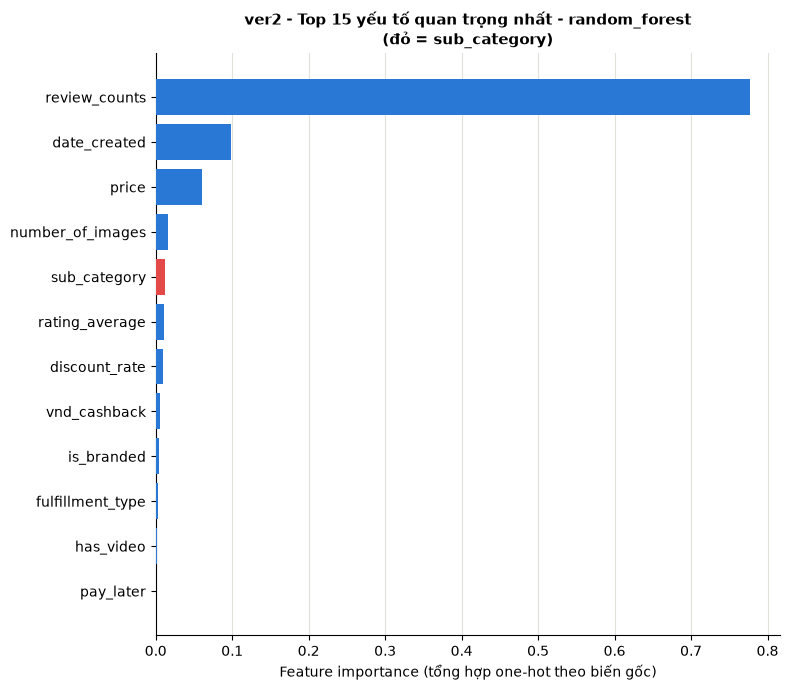

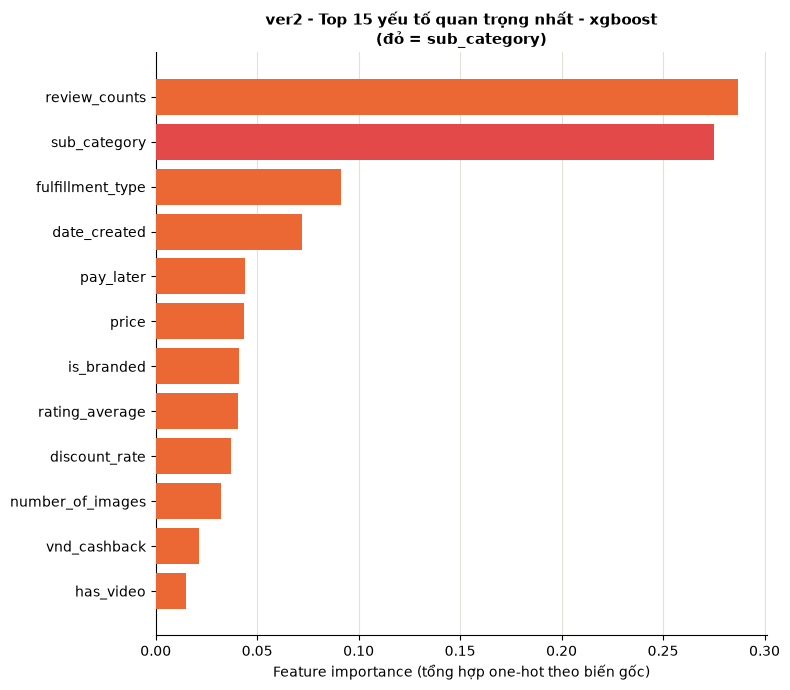

In [9]:
def plot_importance_chart(agg_imp, name, color):
    top_n = agg_imp.head(15).sort_values()
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ["#e34948" if idx == "sub_category" else color for idx in top_n.index]
    ax.barh(top_n.index, top_n.values, color=colors, zorder=3)
    ax.set_xlabel("Feature importance (tổng hợp one-hot theo biến gốc)")
    ax.set_title(f"ver2 - Top 15 yếu tố quan trọng nhất - {name}\n(đỏ = sub_category)",
                 fontsize=11, weight="bold")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"feature_importance_top15_{name}.png"), dpi=150)
    plt.show()


for r in results:
    plot_importance_chart(r["agg_importance"], r["name"], MODEL_COLORS[r["name"]])

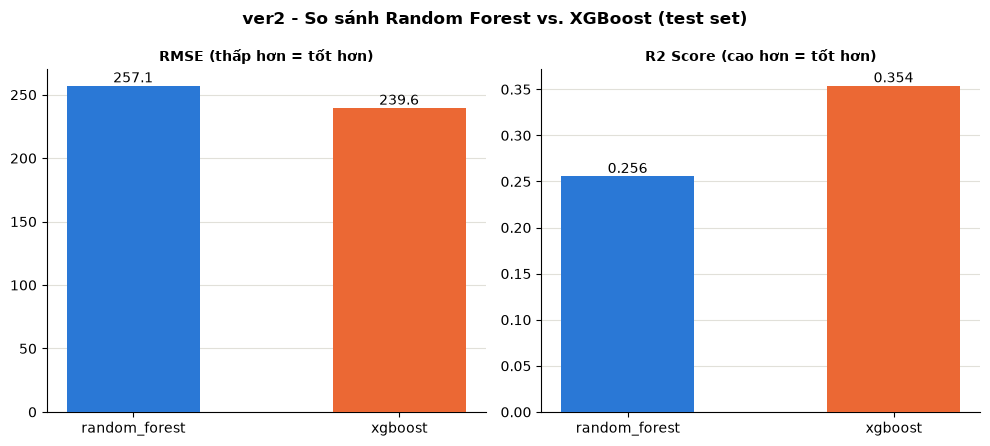

Better model by RMSE: xgboost (RMSE=239.57, R2=0.3540)


In [10]:
def plot_model_comparison(results):
    names = [r["name"] for r in results]
    colors = [MODEL_COLORS[n] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    rmses = [r["rmse"] for r in results]
    bars = axes[0].bar(names, rmses, color=colors, width=0.5, zorder=3)
    for b, v in zip(bars, rmses):
        axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=10)
    axes[0].set_title("RMSE (thấp hơn = tốt hơn)", fontsize=10, weight="bold")
    axes[0].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)

    r2s = [r["r2"] for r in results]
    bars = axes[1].bar(names, r2s, color=colors, width=0.5, zorder=3)
    for b, v in zip(bars, r2s):
        axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    axes[1].set_title("R2 Score (cao hơn = tốt hơn)", fontsize=10, weight="bold")
    axes[1].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)

    for ax in axes:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.set_axisbelow(True)

    fig.suptitle("ver2 - So sánh Random Forest vs. XGBoost (test set)", fontsize=12, weight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "model_comparison_rmse_r2.png"), dpi=150)
    plt.show()


plot_model_comparison(results)

best = min(results, key=lambda r: r["rmse"])
print(f"Better model by RMSE: {best['name']} (RMSE={best['rmse']:.2f}, R2={best['r2']:.4f})")

**Nhận xét — sub_category có phải yếu tố dự báo hàng đầu?**

Ở ver2 (đã loại bỏ đa cộng tuyến), **cả 2 model đều đồng ý** `sub_category` nằm trong top 5:
- Random Forest: `sub_category` xếp **#5/12** (importance = 0.0127) — vào top 5 nhưng khá sát ranh giới, đóng góp rất nhỏ so với `review_counts` (0.777).
- XGBoost: `sub_category` xếp **#2/12** (importance = 0.181) — vào top 5 rõ ràng, chỉ đứng sau `review_counts`.

Khác với ver1 (2 model bất đồng: RF nói KHÔNG vào top 5, XGBoost nói CÓ), ở ver2 sau khi loại `original_price`/`favorite_count` dư thừa, **cả 2 model thống nhất** — kết luận đáng tin cậy hơn.

**Top 5 yếu tố quan trọng nhất:**
- Random Forest: `review_counts` → `date_created` → `price` → `number_of_images` → `sub_category`
- XGBoost: `review_counts` → `sub_category` → `fulfillment_type` → `date_created` → `rating_average`

**Ý nghĩa cho chiến lược kinh doanh ModaVerse:**

`sub_category` có ảnh hưởng thật (không phải nhiễu), nhưng **không phải yếu tố mạnh nhất** — importance của nó (0.013–0.181) vẫn thấp hơn nhiều so với `review_counts` (0.38–0.78). Điều này gợi ý: **chọn đúng ngành hàng để đầu tư là có lợi, nhưng không quyết định** — cách vận hành ở cấp sản phẩm (thời gian đăng bán, giá, số ảnh, kênh giao hàng) mới là đòn bẩy chính. ModaVerse nên tránh chiến lược "dồn hết nguồn lực vào 1-2 danh mục hot" mà thay vào đó chuẩn hóa quy trình vận hành sản phẩm (tối ưu ảnh, đăng bán sớm, chọn đúng fulfillment_type) đồng đều trên mọi danh mục.

**Caveat quan trọng:** `review_counts` đứng đầu ở cả 2 model nhưng là biến "hậu kiểm" — chỉ có sau khi sản phẩm đã bán được, không phải đòn bẩy có thể chủ động điều chỉnh trước khi bán. Khi viết đề xuất chiến lược (Phần 4), nên ưu tiên các yếu tố thực sự hành động được: `date_created` (đăng bán sớm), `price`/`discount_rate`, `number_of_images`, `fulfillment_type`, `is_branded`.
